# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [ ]:
STUDENT_NAME = "Trương Tiến Dương"  # TODO: Họ và tên
STUDENT_ID = "25122064"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Trương Tiến Dương (25122064)


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: /content/data/automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [2]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [3]:
# TODO N1
shifted_logits = logits - np.max(logits, axis = 1, keepdims = True)
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = np.max(class_probabilities, axis=1)

In [4]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
# TODO N2
train_feature_mean = np.mean(X_train, axis = 0)
train_feature_std = np.std(X_train, axis = 0)
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [10]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [11]:
# TODO N3
correct_mask = predicted_classes == true_labels
high_confidence_mask = confidence_scores >= confidence_threshold
review_mask = ~correct_mask | ~high_confidence_mask
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [12]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [13]:
# TODO N4
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
augmented_batch = np.flip(normalized_batch, axis=2).copy()
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

1. Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports.
2. Dấu `?`.
3. `symboling` có ý nghĩa là mức độ rủi ro bảo hiểm của xe.

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [14]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
print(raw_shape)
raw_missing_marker_count = (raw_df == "?").sum().sum()
print(f"missing values: {raw_missing_marker_count}")

(205, 26)
missing values: 59


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [16]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [17]:
# TODO D2
df_clean = raw_df.replace("?", np.nan).copy()
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])
missing_by_column = df_clean.isna().sum()
print(df_clean.dtypes)
print(missing_by_column)

symboling              int64
normalized_losses    float64
make                  object
fuel_type             object
aspiration            object
num_doors             object
body_style            object
drive_wheels          object
engine_location       object
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_type           object
num_cylinders         object
engine_size            int64
fuel_system           object
bore                 float64
stroke               float64
compression_ratio    float64
horsepower           float64
peak_rpm             float64
city_mpg               int64
highway_mpg            int64
price                float64
dtype: object
symboling             0
normalized_losses    41
make                  0
fuel_type             0
aspiration            0
num_doors             2
body_style            0
drive_wheels          0
engine_location       0
wheel_base      

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [19]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [20]:
# TODO D3
analysis_df = df_clean[AUTO_FEATURES].dropna()
X_auto = analysis_df.to_numpy(dtype=np.float64)
auto_feature_mean = np.mean(X_auto, axis=0)
auto_feature_std = np.std(X_auto, axis=0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [23]:
# TODO D4
price_index = AUTO_FEATURES.index('price')
price_z = X_auto_scaled[ : , price_index]
price_outlier_mask = np.abs(price_z) > 2
price_outliers = analysis_df[price_outlier_mask]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [27]:
# TODO D5
corr_matrix = np.corrcoef(X_auto_scaled, rowvar=False)
engine_price_corr = corr_matrix[AUTO_FEATURES.index('engine_size')][AUTO_FEATURES.index('price')]
print(f"engine_price_corr = {engine_price_corr}")
price_by_body_style = df_clean.groupby(by=['body_style'])['price'].mean().sort_values()
print(price_by_body_style)

engine_price_corr = 0.8738869517981525
body_style
hatchback       9957.441176
wagon          12371.960000
sedan          14459.755319
convertible    21890.500000
hardtop        22208.500000
Name: price, dtype: float64


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

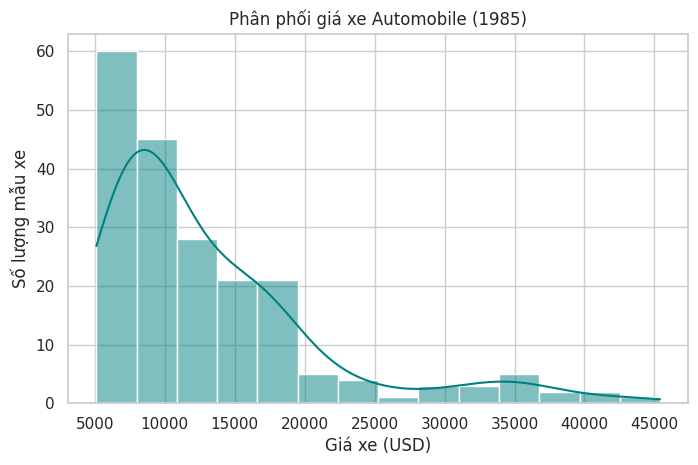

In [28]:
# TODO M2.1: histogram/KDE của price
sns.histplot(data=df_clean, x="price", kde=True, color="teal")
plt.title("Phân phối giá xe Automobile (1985)")
plt.xlabel("Giá xe (USD)")
plt.ylabel("Số lượng mẫu xe")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Phân phối giá xe bị lệch trái. Đa số mẫu xe được bán ở giá từ 15000 USD trở xuống.

## M2.2 Dataset có cân bằng theo body style không?

/tmp/ipykernel_2425/227441461.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x="body_style", order=df_clean["body_style"].value_counts().index, palette="viridis")


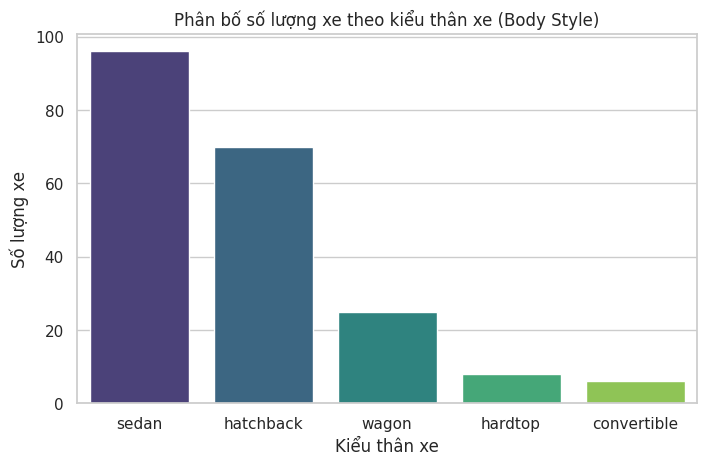

In [29]:
# TODO M2.2: countplot của body_style
sns.countplot(data=df_clean, x="body_style", order=df_clean["body_style"].value_counts().index, palette="viridis")
plt.title("Phân bố số lượng xe theo kiểu thân xe (Body Style)")
plt.xlabel("Kiểu thân xe")
plt.ylabel("Số lượng xe")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
DỮ liệu không cân bằng. `sedan` và `hatchback` nhiều đáng kể so với những dòng còn lại.

## M2.3 Price khác nhau theo body style ra sao?

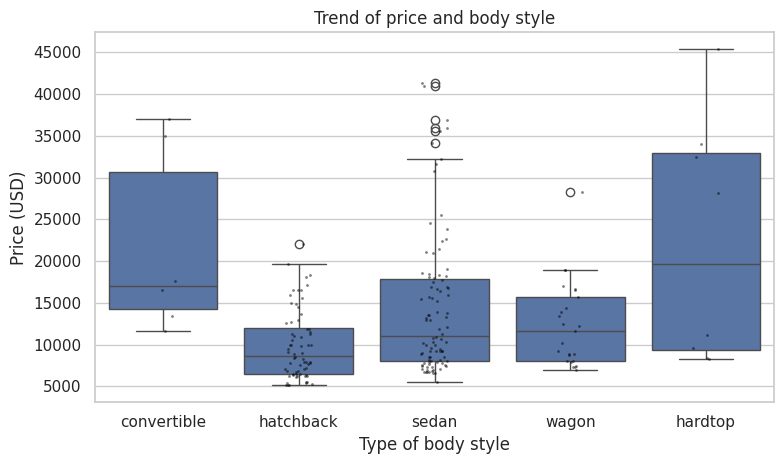

In [30]:
# TODO M2.3: boxplot price theo body_style
sns.boxplot(data=df_clean, x='body_style', y='price')
sns.stripplot(data=df_clean, x='body_style', y='price', alpha=0.5, color='black', size=2)
plt.xlabel("Type of body style")
plt.ylabel("Price (USD)")
plt.title("Trend of price and body style")
plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
`hardtop` và `convertible` có giá trung vị cao nhất, còn `hatchback` thấp nhất.

## M2.4 Engine size liên quan thế nào tới price?

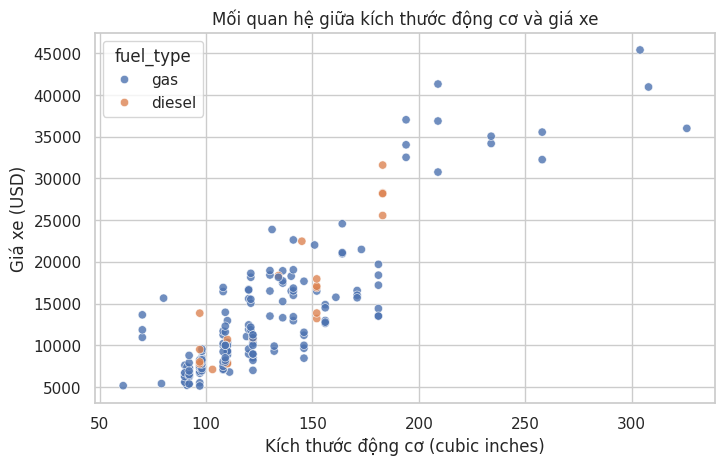

In [33]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
sns.scatterplot(data=df_clean, x="engine_size", y="price", hue="fuel_type", alpha=0.8)
plt.title("Mối quan hệ giữa kích thước động cơ và giá xe")
plt.xlabel("Kích thước động cơ (cubic inches)")
plt.ylabel("Giá xe (USD)")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Có mối tương quan tuyến tính: kích thước động cơ càng lớn thì giá xe càng cao.

## M2.5 Các feature numeric tương quan ra sao?

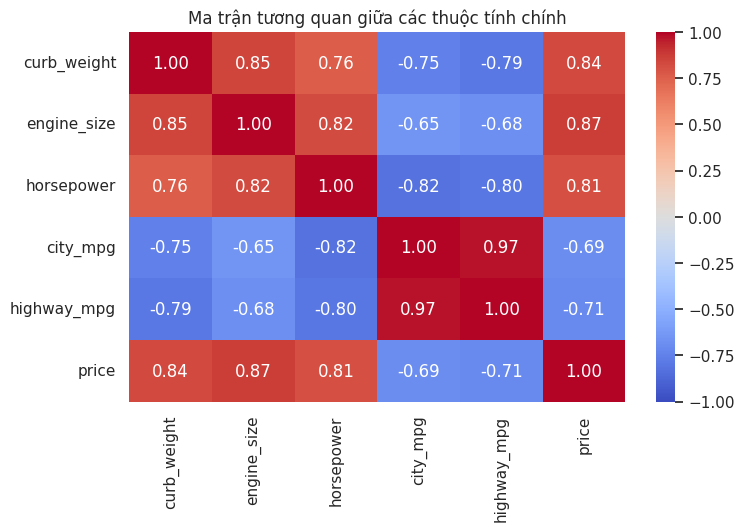

In [31]:
# TODO M2.5: correlation heatmap
corr_matrix = analysis_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Ma trận tương quan giữa các thuộc tính chính")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
`price` tương quan thuận mạnh với `engine_size` (0.87), `horsepower` (0.81) và `curb_weight` (0.83). Ngược lại, `price` tương quan nghịch mạnh với hiệu suất nhiên liệu (`city_mpg` và `highway_mpg`).

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

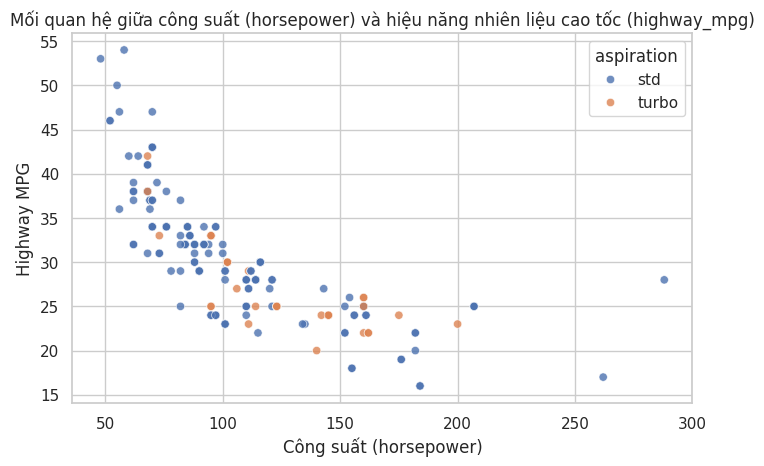

In [32]:
# TODO M2.6: biểu đồ tự chọn
sns.scatterplot(data=df_clean, x="horsepower", y="highway_mpg", hue="aspiration", alpha=0.8)
plt.title("Mối quan hệ giữa công suất (horsepower) và hiệu năng nhiên liệu cao tốc (highway_mpg)")
plt.xlabel("Công suất (horsepower)")
plt.ylabel("Highway MPG")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
Công suất và hiệu năng nhiên liệu tương quan nghịch.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->